In [22]:
# Demo file for working with univariate data
# live entstanden in der Vorlesung GIB Mathematik2, 18.03.2026
#
# copyright: Barbara Staehle, HTWG Konstanz
# bstaehle@htwg-konstanz.de

# import library we use for plotting and calculating
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statistics as stat

# Fortsetzung Beispiel von letzter Woche: Körpergröße der anwesenden Studierenden

In [3]:
# body length in cm of students attending the lecture
x = [170, 161, 173, 176, 172, 189, 167, 173]
print(x)


[170, 161, 173, 176, 172, 189, 167, 173]


In [5]:
# count how often each value occurs
values, counts = np.unique(x,return_counts=True)
print(f'Werte in der Liste: {values}')
print(f'Absolute Häufigkeiten: {counts}')


Werte in der Liste: [161 167 170 172 173 176 189]
Absolute Häufigkeiten: [1 1 1 1 2 1 1]


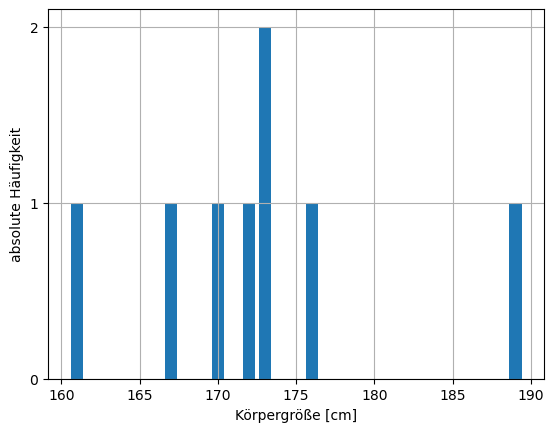

In [6]:
# show as bar plot
plt.bar(values,counts)
plt.grid(True)
plt.xlabel('Körpergröße [cm]')
plt.ylabel('absolute Häufigkeit')
plt.yticks([0,1,2])
plt.show()

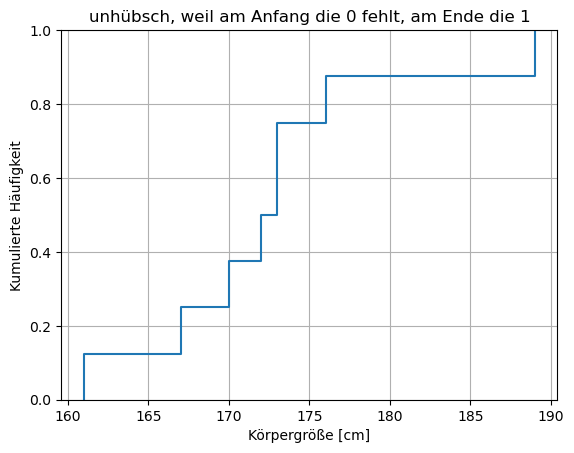

In [7]:
plt.ecdf(x)
plt.xlabel('Körpergröße [cm]')
plt.ylabel('Kumulierte Häufigkeit')
plt.grid(True)
plt.title('unhübsch, weil am Anfang die 0 fehlt, am Ende die 1')
plt.show()

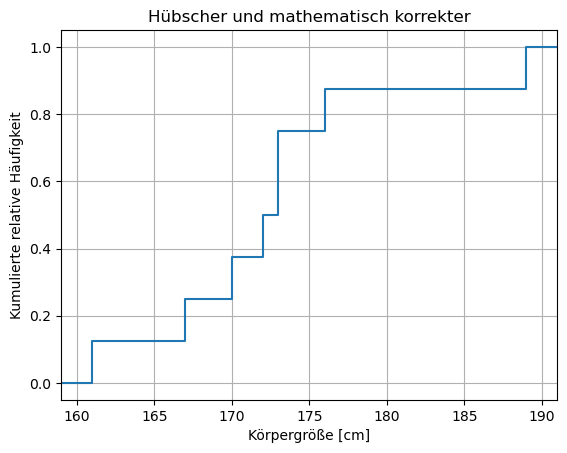

In [8]:
# mit Funktionen cumsum und step (aufwändiger aber hübscher)
x = np.array(x)
x2 = np.append(x, [min(x)-5,max(x)+5])
y = np.array(range(1,len(x)+1))/len(x)
y = np.append(y, [0, 1])
plt.step(sorted(x2),sorted(y),where='post')
plt.xlim(min(x)-2,max(x)+2)
plt.grid(True)
plt.xlabel('Körpergröße [cm]')
plt.ylabel('Kumulierte relative Häufigkeit')
plt.title('Hübscher und mathematisch korrekter')
plt.show()

# neues Beispiel: lies die Daten aus der Umfragen "zehn Fragen" ein 

In [12]:
# read data from excelcfile, with separators 
# for excel-file, see Moodle!
umfrage = pd.read_excel('../../data/zehn_Fragen_ss26_clean.xlsx')

# Daten ausgeben
print(umfrage)

    Antworten           Abgegeben:                          Kurs  \
0        7518  18.03.2026 09:05:16  Mathematik 2 (GIB) B.Staehle   
1        7515  18.03.2026 09:03:56  Mathematik 2 (GIB) B.Staehle   
2        7517  18.03.2026 09:05:00  Mathematik 2 (GIB) B.Staehle   
3        7514  18.03.2026 09:03:42  Mathematik 2 (GIB) B.Staehle   
4        7513  18.03.2026 09:03:40  Mathematik 2 (GIB) B.Staehle   
5        7511  18.03.2026 09:03:17  Mathematik 2 (GIB) B.Staehle   
6        7512  18.03.2026 09:03:36  Mathematik 2 (GIB) B.Staehle   
7        7516  18.03.2026 09:04:57  Mathematik 2 (GIB) B.Staehle   
8        7580  19.03.2026 12:39:11    Stochastik (AIN) B.Staehle   
9        7578  19.03.2026 12:38:36    Stochastik (AIN) B.Staehle   
10       7576  19.03.2026 12:38:27    Stochastik (AIN) B.Staehle   
11       7579  19.03.2026 12:38:53    Stochastik (AIN) B.Staehle   
12       7575  19.03.2026 12:38:21    Stochastik (AIN) B.Staehle   
13       7581  19.03.2026 12:39:31    Stochastik

In [13]:
# wir konzentrieren uns auf das Stochastik-Vorwissen
wissen = umfrage['Q05_Stochastik-Vorwissen']
print(wissen)

0     4
1     1
2     2
3     2
4     4
5     0
6     3
7     7
8     8
9     2
10    4
11    3
12    7
13    6
14    3
15    1
16    4
17    0
18    6
19    2
20    5
21    4
22    5
23    1
24    6
Name: Q05_Stochastik-Vorwissen, dtype: int64


Werte in der Liste: [0 1 2 3 4 5 6 7 8]
Absolute Häufigkeiten: [2 3 4 3 5 2 3 2 1]


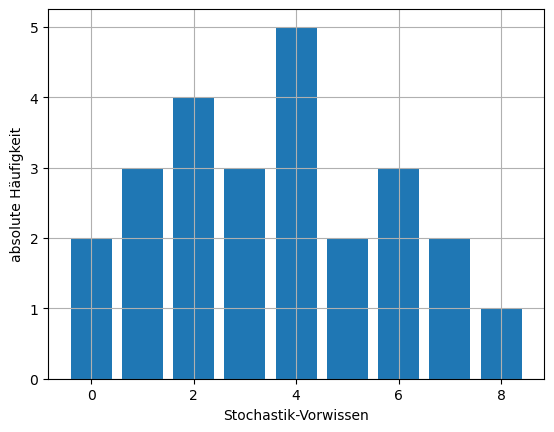

In [14]:
# count how often each value occurs
values, counts = np.unique(wissen,return_counts=True)
print(f'Werte in der Liste: {values}')
print(f'Absolute Häufigkeiten: {counts}')

# show as bar plot 
plt.bar(values,counts)
plt.grid(True)
plt.xlabel('Stochastik-Vorwissen')
plt.ylabel('absolute Häufigkeit')
plt.show()

In [16]:
# Trennen nach AIN- und GIB-Studierenden
um_gib = umfrage[umfrage['Kurs'].str.contains('Mathematik')]
#print(um_gib)
um_ain = umfrage[umfrage['Kurs'].str.contains('Stochastik')]
#print(um_ain)

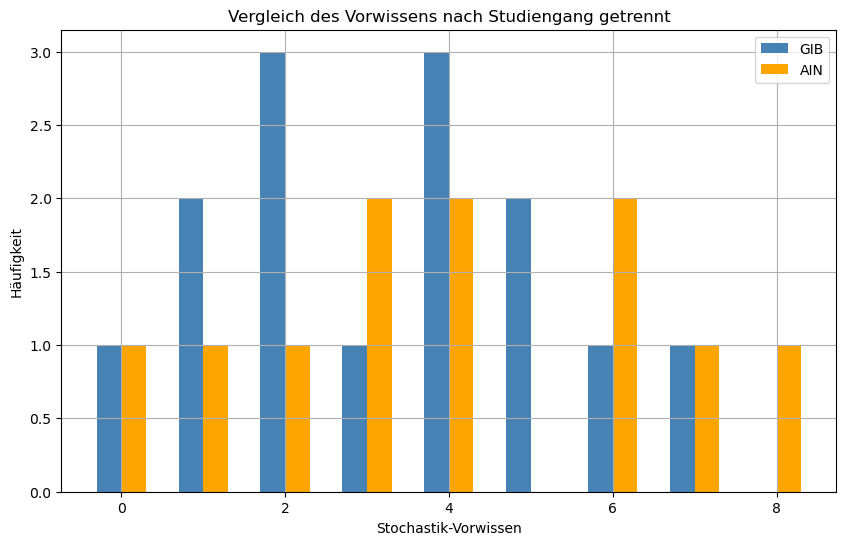

In [17]:
# Filtere die Daten für die beiden Gruppen
gib_data = umfrage[umfrage['Kurs'].str.contains('Mathematik', case=False, na=False)]['Q05_Stochastik-Vorwissen']
ain_data = umfrage[umfrage['Kurs'].str.contains('Stochastik', case=False, na=False)]['Q05_Stochastik-Vorwissen']

# Unique Werte
unique_values = sorted(set(gib_data) | set(ain_data))

# Position der Balken
# falscher Vorschlag von LeChat, wir möchten ja nicht die Anzahl der eindeutigen Werte, sondern die eindeutigen Werte selbst auf der x-Achse haben
#x = np.arange(len(unique_values))
x = np.array(unique_values)
width = 0.3  # Breite der Balken

# Plotten der Histogramme (als Balkendiagramm nebeneinander)
plt.figure(figsize=(10, 6))

# Balken für "Mathematik" in Blau
plt.bar(x - width/2, [gib_data.value_counts().get(val, 0) for val in unique_values], width, color='steelblue', label='GIB')

# Balken für "Stochastik" in Orange
plt.bar(x + width/2, [ain_data.value_counts().get(val, 0) for val in unique_values], width, color='orange', label='AIN')

# Titel und Beschriftungen
plt.title('Vergleich des Vorwissens nach Studiengang getrennt')
plt.xlabel('Stochastik-Vorwissen')
plt.ylabel('Häufigkeit')
plt.legend()
plt.grid(True)

# Zeige das Plot an
plt.show()

## Berechne Mittelwert, Median, Modalwert des Vorwissens

In [18]:
# Mittelwert 
# die Zahl genau ausgeben
print("Mittelwert Vorwissen gesamt:", np.mean(wissen))
# gerundet auf drei Nachkommastellen
print(f"Mittelwert GIB-Vorwissen gerundet: {np.mean(gib_data):.3f}")
print("Mittelwert AIN-Vorwissen genau:", np.mean(ain_data))

Mittelwert Vorwissen gesamt: 3.6
Mittelwert GIB-Vorwissen gerundet: 3.286
Mittelwert AIN-Vorwissen genau: 4.0


In [20]:
print("Median Vorwissen gesamt:", np.median(wissen))
print("Median GIB-Vorwissen:", np.median(gib_data))
print("Median AIN-Vorwissen:", np.median(ain_data))

Median Vorwissen gesamt: 4.0
Median GIB-Vorwissen: 3.5
Median AIN-Vorwissen: 4.0


In [23]:
print("Modalwert(e) Vorwissen gesamt:", stat.multimode(wissen))
print("Modalwert(e) GIB-Vorwissen:", stat.multimode(gib_data))
print("Modalwert(e) AIN-Vorwissen:", stat.multimode(ain_data))

Modalwert(e) Vorwissen gesamt: [4]
Modalwert(e) GIB-Vorwissen: [4, 2]
Modalwert(e) AIN-Vorwissen: [4, 3, 6]
